In [57]:
import matplotlib.pyplot
import matplotlib.colors
import pandas
from pathlib import Path

In [58]:
def parse_vegeta_log(file_path : str) -> pandas.DataFrame:
    columns = ['timestamp_ns', 'status', 'latency_ns']
    return pandas.read_csv(file_path, header=None, usecols=[0, 1, 2], names=columns)

def parse_summary_log(file_path : str) -> pandas.DataFrame:
    columns = ['timestamp_ns', 'cpu', 'event', 'value', 'enabled', 'running']
    return pandas.read_csv(file_path, header=None, names=columns)

def parse_interface_log(file_path : str) -> pandas.DataFrame:
    columns = ['timestamp_ns', 'cpu', 'interface', 'rx_packets', 'rx_bytes', 'tx_packets', 'tx_bytes']
    return pandas.read_csv(file_path, header=None, names=columns)

In [65]:
def parse_summary_results(event : str) -> pandas.DataFrame:
    records = []

    for path in Path('results/').iterdir():
        if path.is_file() and path.name == '.gitkeep':
            continue

        replica_count      = int(path.name.split()[0].split('_')[0])
        request_per_second = int(path.name.split()[0].split('_')[1])

        summary_log_file_path = path / 'summary.log'

        summary_log = parse_summary_log(summary_log_file_path)

        value = summary_log.loc[summary_log['event'] == event, 'value'].sum()

        records.append({
            'replica_count': replica_count,
            'request_per_second': request_per_second,
            'value': value,
        })

    data_frame = pandas.DataFrame.from_records(records)

    return data_frame.pivot(
            index='replica_count',
            columns='request_per_second',
            values='value').sort_index(axis=0).sort_index(axis=1)

def plot_summary_results(event : str) -> None:
    data_frame = parse_summary_results(event)

    colors = ['#fde725', '#b5de2b', '#6ece58', '#35b779', '#1f9e89', '#26828e', '#31688e', '#3e4989', '#482878', '#440154']
    color_map = matplotlib.colors.ListedColormap(colors)

    figure, axes = matplotlib.pyplot.subplots(figsize=(10, 8))
    image = axes.imshow(data_frame, color_map)

    colorbar = figure.colorbar(image, ax=axes)
    colorbar.set_label(event)

    axes.set_xticks(range(len(data_frame.columns)))
    axes.set_xticklabels(data_frame.columns)
    axes.set_yticks(range(len(data_frame.index)))
    axes.set_yticklabels(data_frame.index)

    for row_index, replica_count in enumerate(data_frame.index):
        for col_index, request_per_second in enumerate(data_frame.columns):
            value = data_frame.iloc[row_index, col_index]
            if pandas.isna(value):
                continue

            luminance = sum(c * w for c, w in zip(image.cmap(image.norm(value))[:3], (0.299, 0.587, 0.114)))
            text_color = 'black' if luminance > 0.5 else 'white'

            axes.text(col_index, row_index, f"{value}", ha='center', va='center', color=text_color)

    axes.set_title(f"{event} across replicas and request per second (burn=20ms)")
    axes.set_xlabel("Request per second")
    axes.set_ylabel("Replica count")
    matplotlib.pyplot.tight_layout()

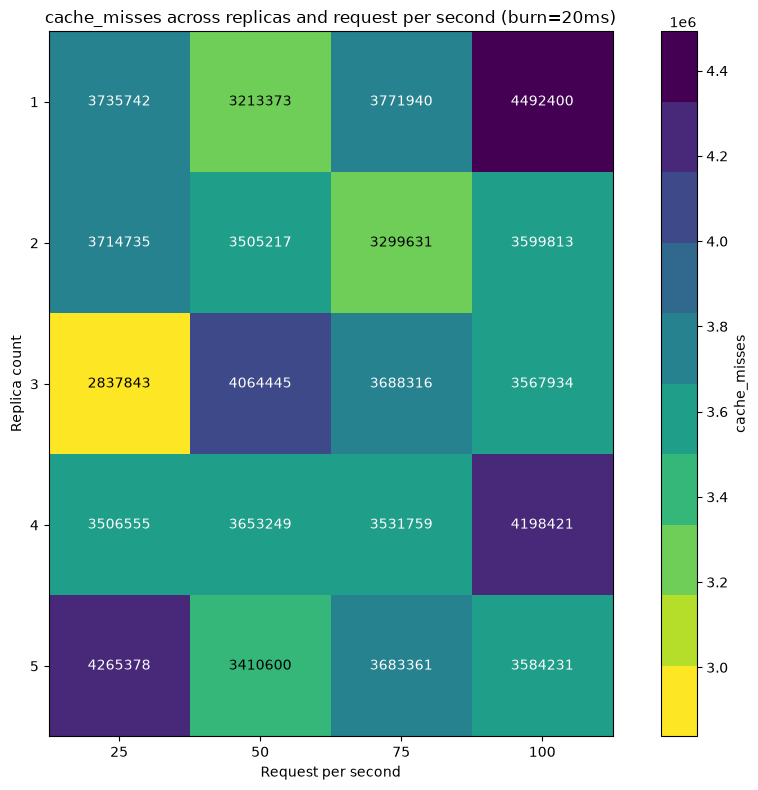

In [73]:
plot_summary_results('cache_misses')

In [51]:
def parse_p99_results() -> pandas.DataFrame:
    records = []

    for path in Path('results/').iterdir():
        if path.is_file() and path.name == '.gitkeep':
            continue

        replica_count      = int(path.name.split()[0].split('_')[0])
        request_per_second = int(path.name.split()[0].split('_')[1])

        vegeta_log_file_path = path / 'vegeta.log'

        avg_p99 = parse_vegeta_log(vegeta_log_file_path)['latency_ns'].quantile(0.99).mean() / 1e6

        records.append({
            'replica_count': replica_count,
            'request_per_second': request_per_second,
            'latency_ms': avg_p99,
        })

    data_frame = pandas.DataFrame.from_records(records)

    return data_frame.pivot(
            index='replica_count',
            columns='request_per_second',
            values='latency_ms').sort_index(axis=0).sort_index(axis=1)

def plot_p99_results() -> None:
    data_frame = parse_p99_results()

    colors = ['#fde725', '#b5de2b', '#6ece58', '#35b779', '#1f9e89', '#26828e', '#31688e', '#3e4989', '#482878', '#440154']
    color_map = matplotlib.colors.ListedColormap(colors)

    boundaries = [20, 40, 80, 160, 320, 640, 1280, 30000]
    norm = matplotlib.colors.BoundaryNorm(boundaries, color_map.N)

    figure, axes = matplotlib.pyplot.subplots(figsize=(10, 8))
    image = axes.imshow(data_frame, color_map, norm=norm)

    colorbar = figure.colorbar(image, ax=axes)
    colorbar.set_label("P99 Latency (ms)")

    axes.set_xticks(range(len(data_frame.columns)))
    axes.set_xticklabels(data_frame.columns)
    axes.set_yticks(range(len(data_frame.index)))
    axes.set_yticklabels(data_frame.index)

    for row_index, replica_count in enumerate(data_frame.index):
        for col_index, request_per_second in enumerate(data_frame.columns):
            value = data_frame.iloc[row_index, col_index]
            if pandas.isna(value):
                continue

            luminance = sum(c * w for c, w in zip(image.cmap(image.norm(value))[:3], (0.299, 0.587, 0.114)))
            text_color = 'black' if luminance > 0.5 else 'white'

            axes.text(col_index, row_index, f"{value:.1f}ms", ha='center', va='center', color=text_color)

    axes.set_title("Average P99 Latency across replicas and request per second (burn=20ms)")
    axes.set_xlabel("Request per second")
    axes.set_ylabel("Replica count")
    matplotlib.pyplot.tight_layout()
    

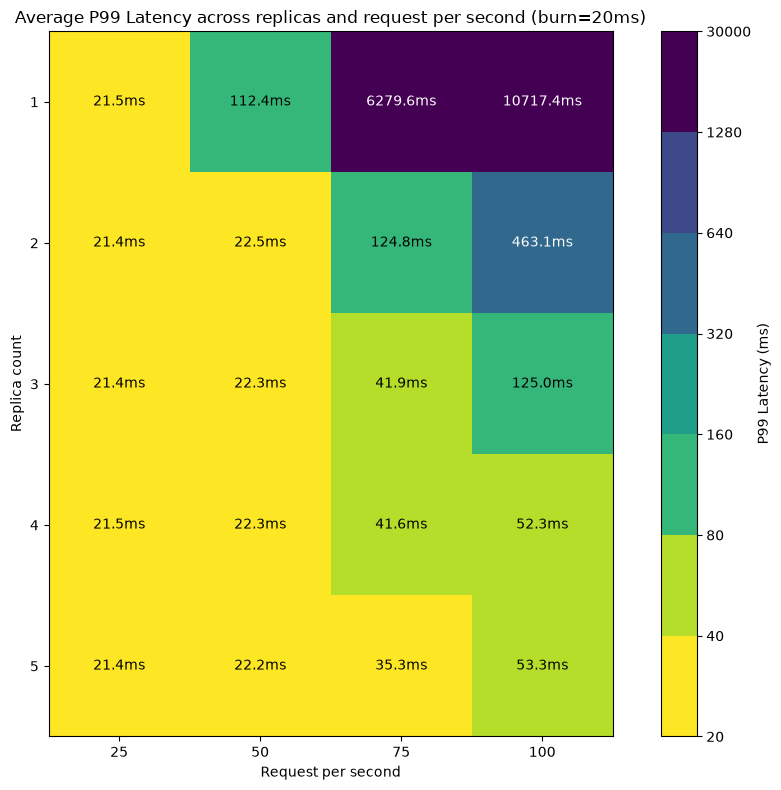

In [52]:
plot_p99_results()